Preprocessing Step 5:

Visualizing the signals and data points.
Get first insights of the underlying distribution.

In [1]:
from pathlib import Path
import os
from tqdm import tqdm
from glob import glob
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import probplot
import math
from helperfunctions import intern_constants as ic

In [2]:
files = glob(os.path.join(ic.PATH_IMPUTED, "*.csv"))

In [3]:
all_wt_data = []
for file in tqdm(files):
    df = pd.read_csv(file)
    all_wt_data.append(df)

df_turbines = pd.concat(all_wt_data, ignore_index=True)
cols = [sig for sig in df_turbines.columns if sig not in [ic.WT_ID, ic.TS_COL]]

100%|██████████| 14/14 [00:26<00:00,  1.92s/it]


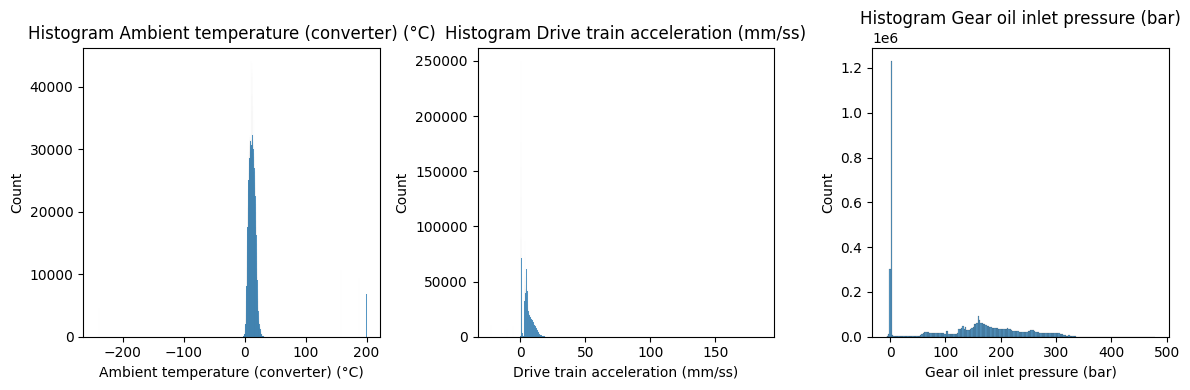

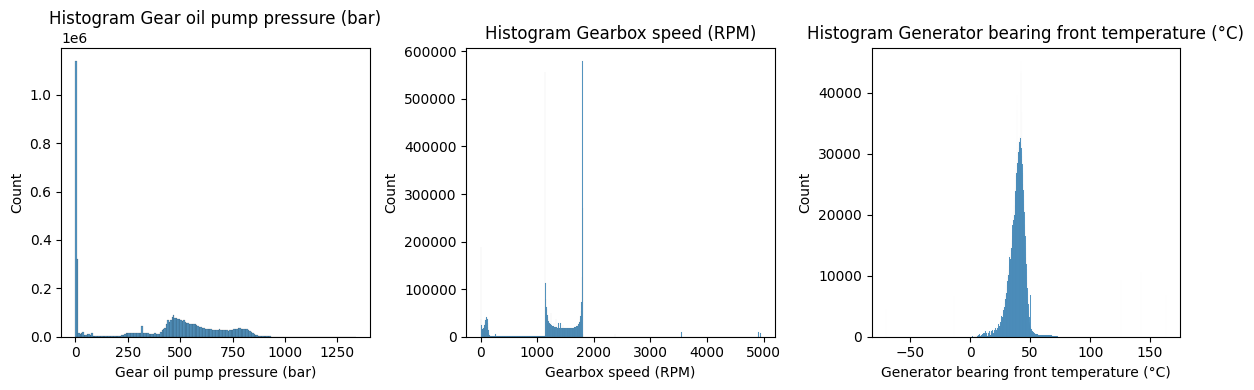

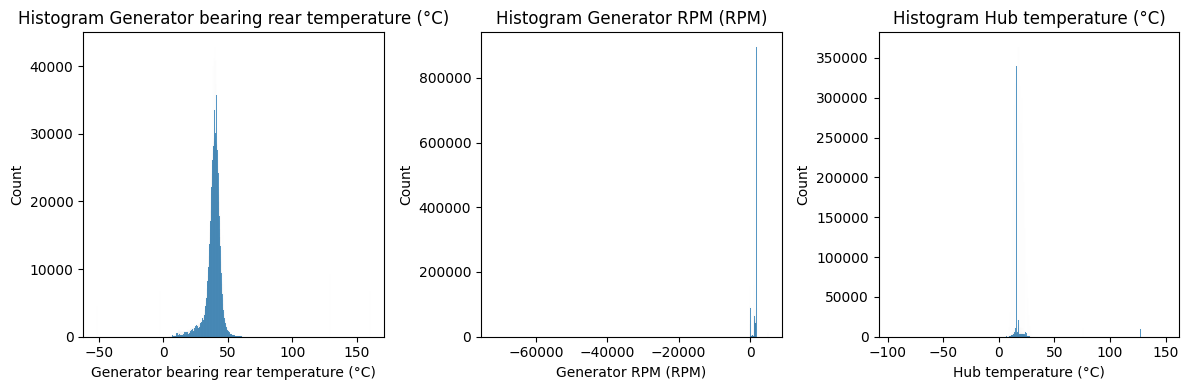

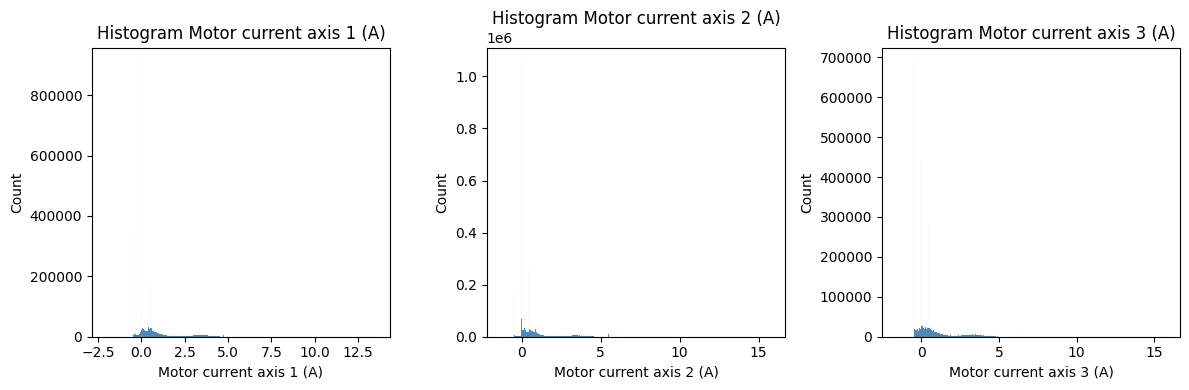

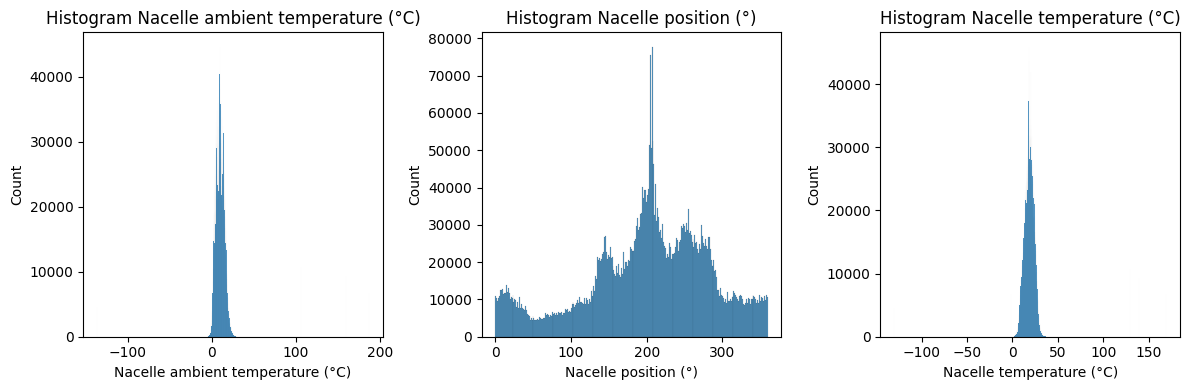

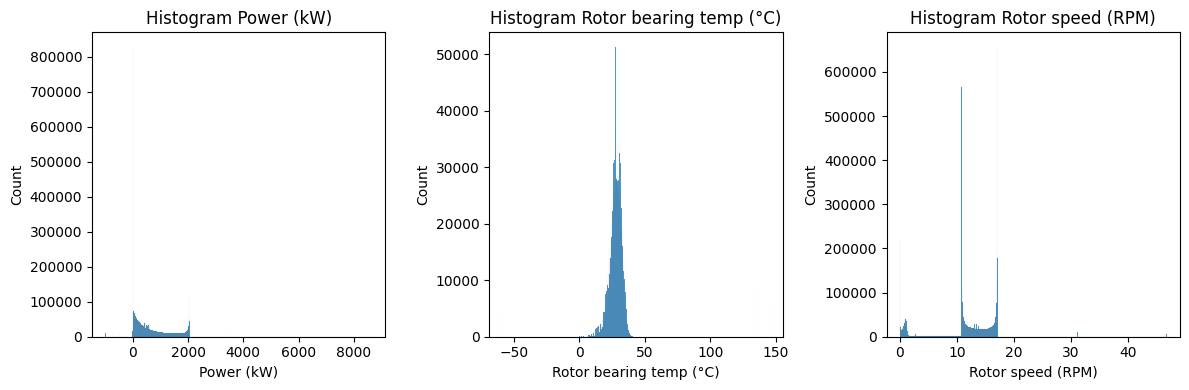

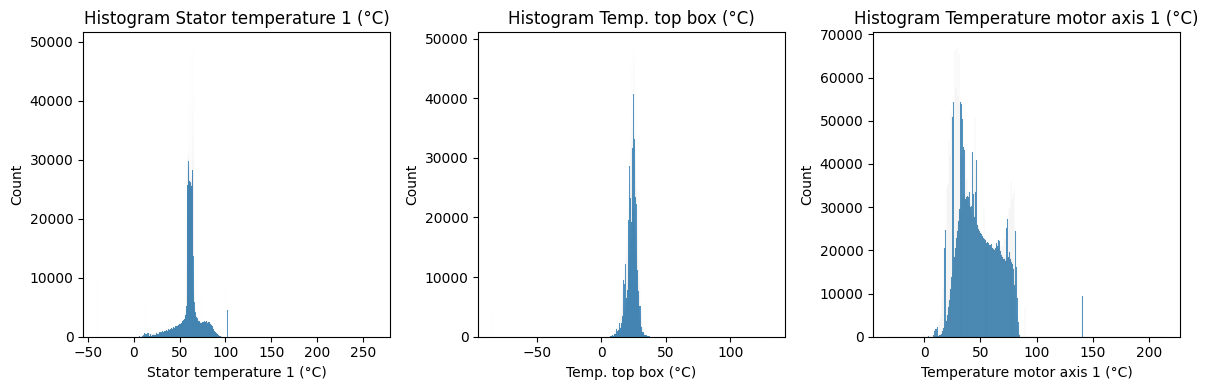

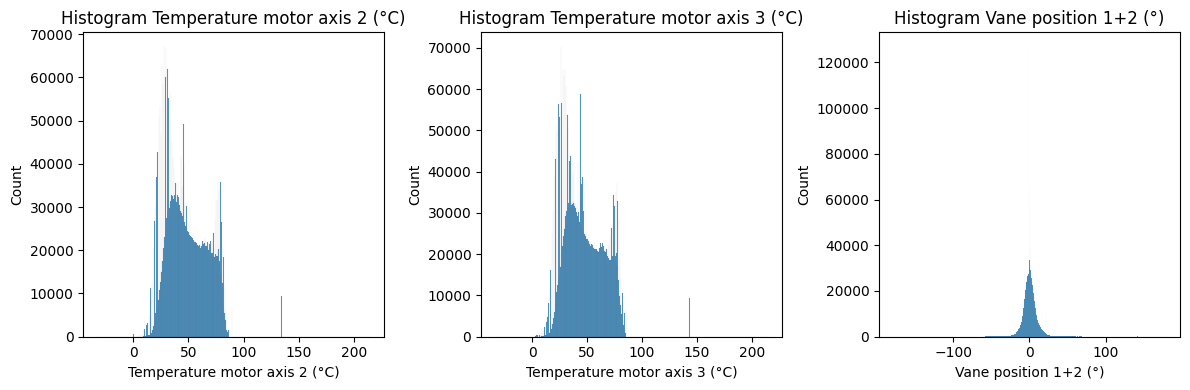

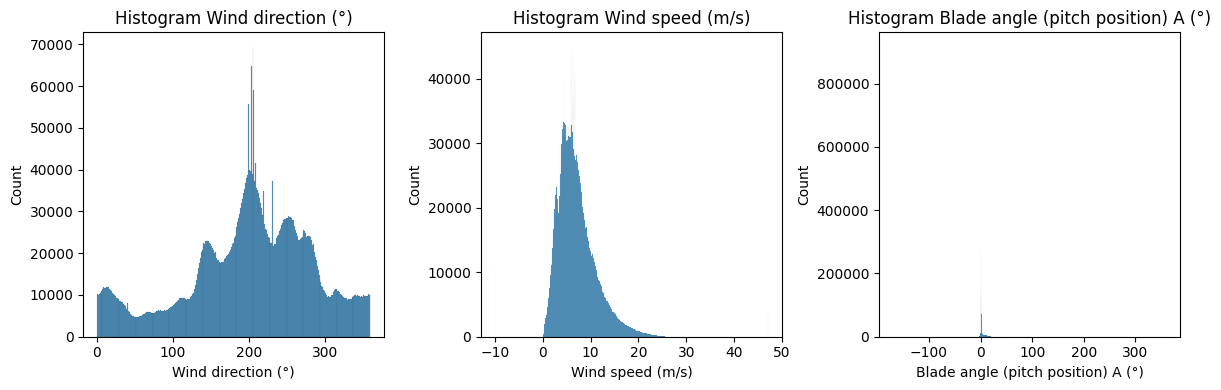

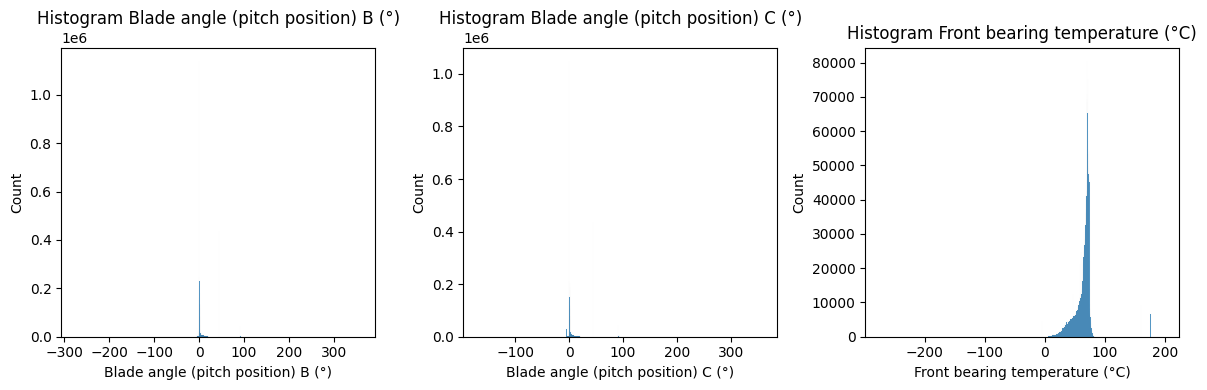

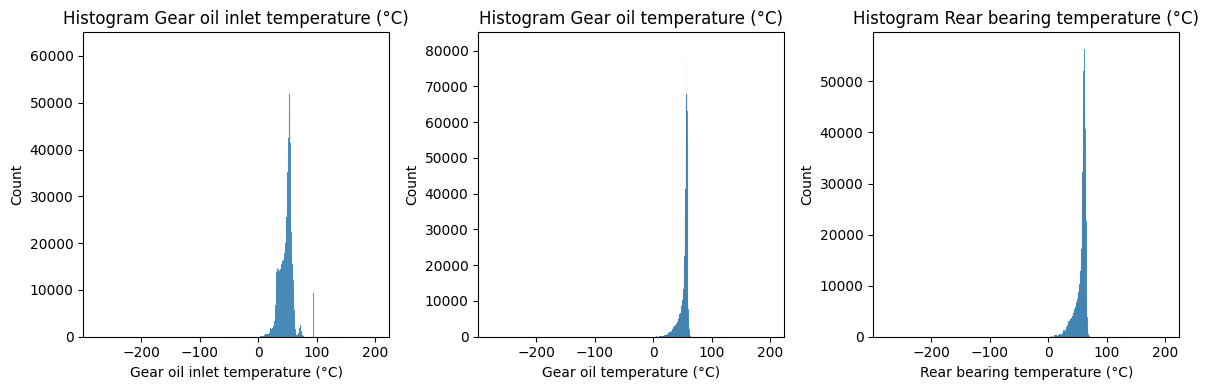

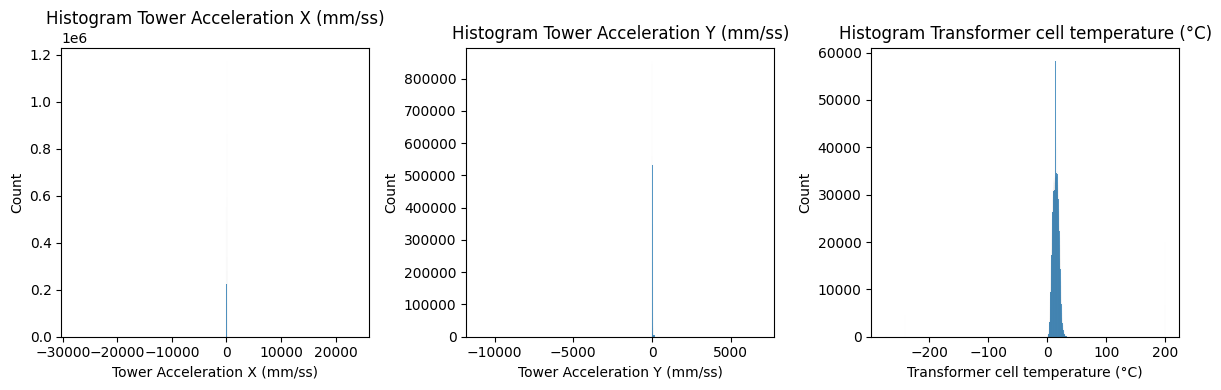

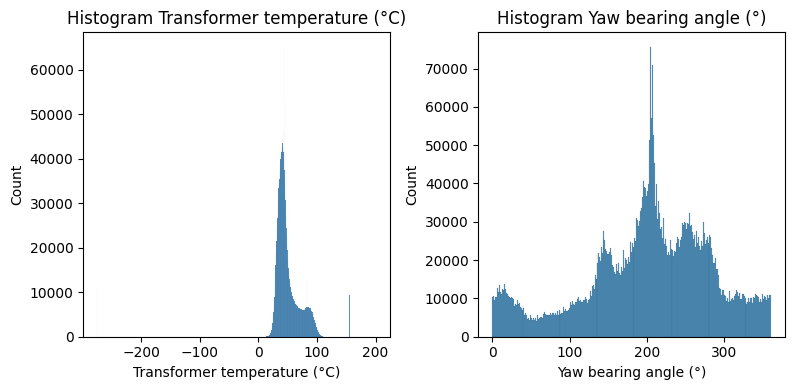

In [4]:
signals_per_fig = 3
cols_per_row = 3
figscale = 4

for idx in range(0, len(cols), signals_per_fig):
    subset = cols[idx:idx+signals_per_fig]
    n_subplots = len(subset)
    n_rows = math.ceil(n_subplots / cols_per_row)
    
    fig, axes = plt.subplots(
        n_rows, cols_per_row,
        figsize=(figscale*cols_per_row, figscale*n_rows),
        squeeze=False
    )
    for ax, sig in zip(axes.flatten(), subset):
        sns.histplot(data=df_turbines[cols], x=sig, ax=ax)
        ax.set_title(f"Histogram {sig}")
        ax.set_xlabel(sig)
        
    for empty_ax in axes.flatten()[n_subplots:]:
        empty_ax.remove()
    
    plt.tight_layout()
    plt.show()

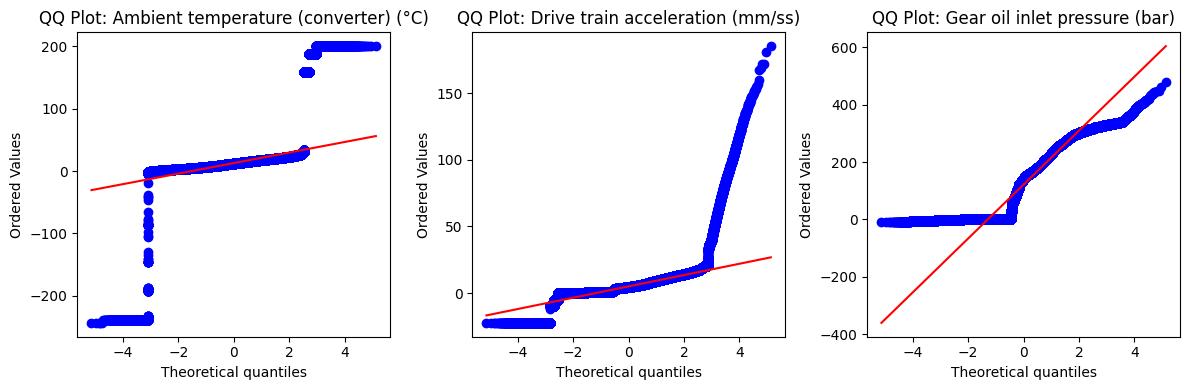

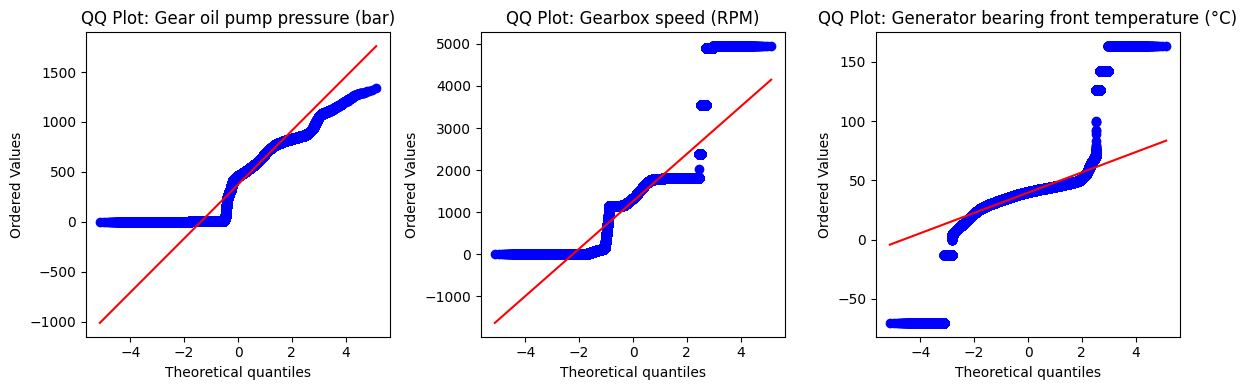

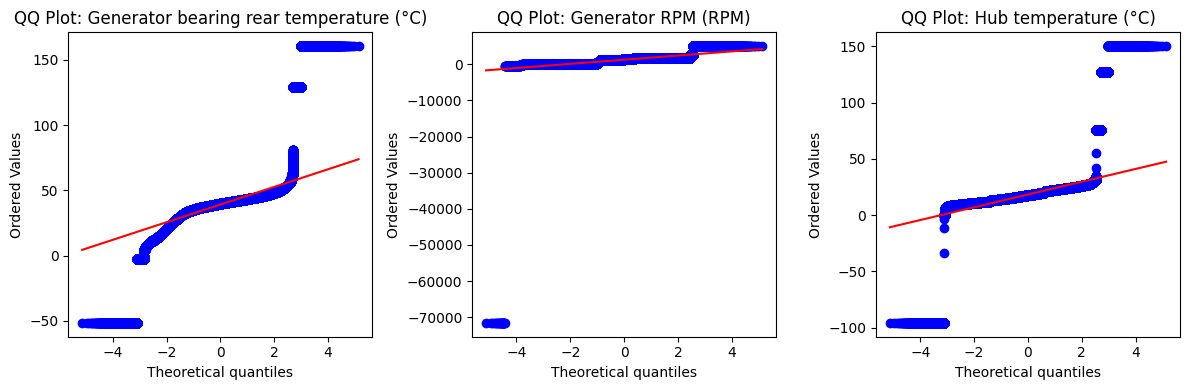

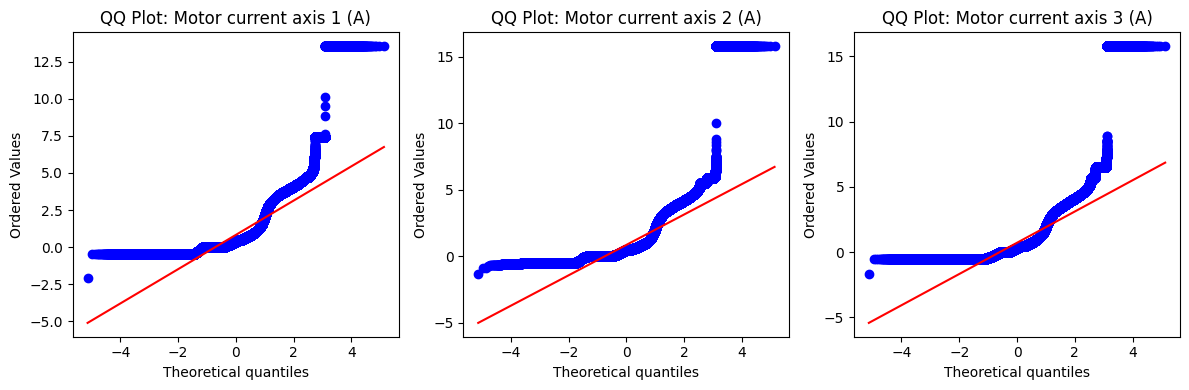

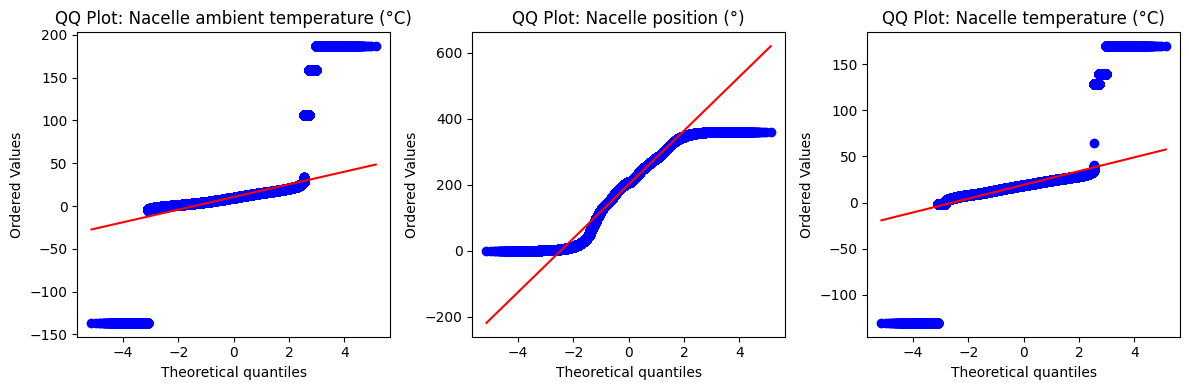

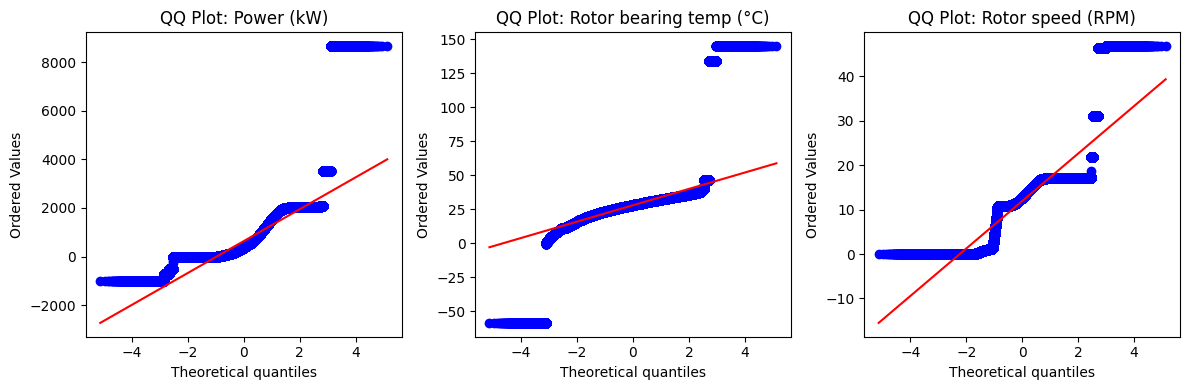

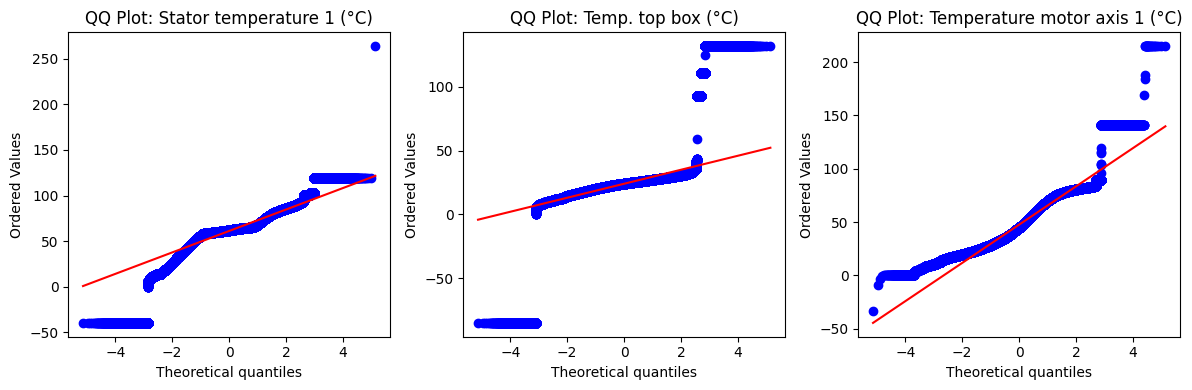

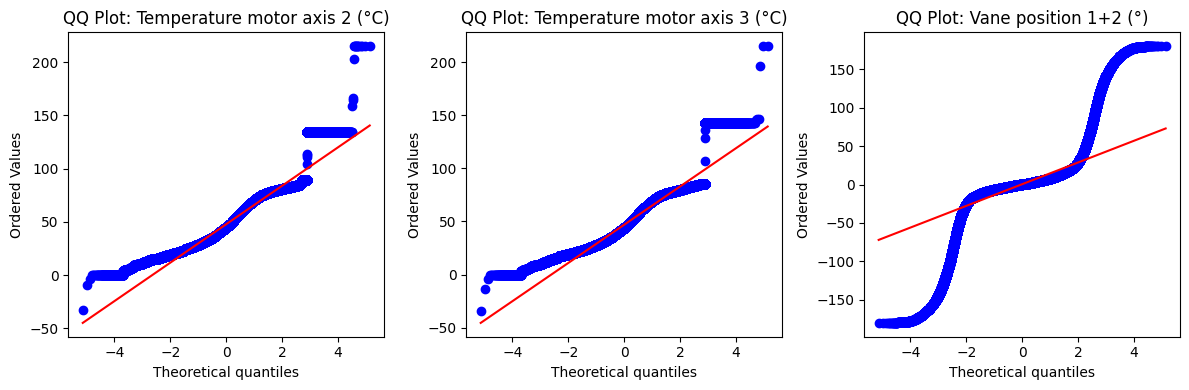

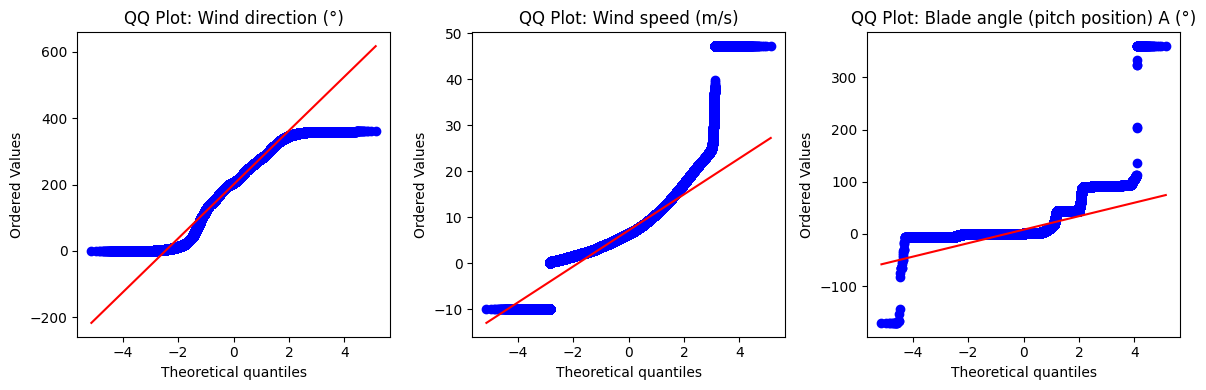

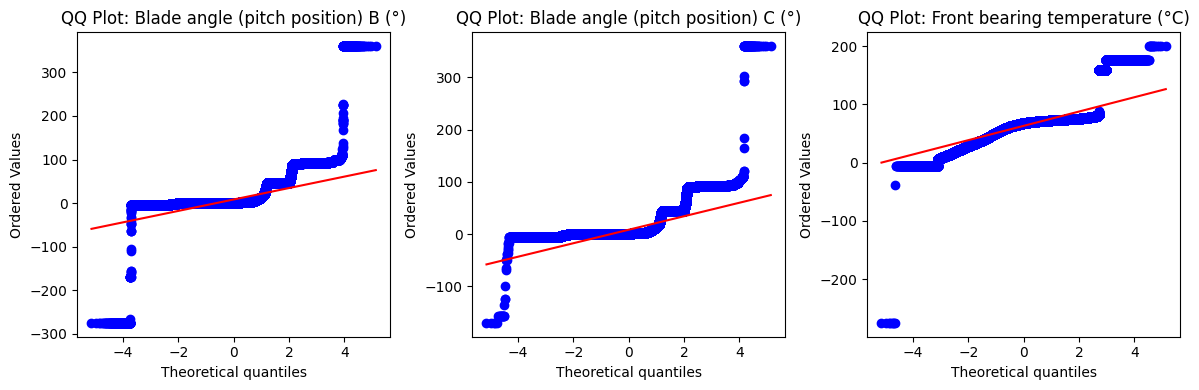

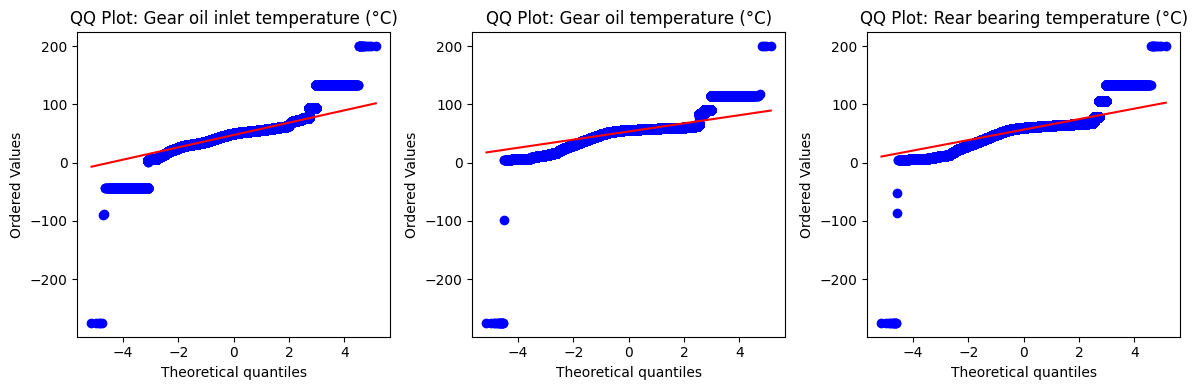

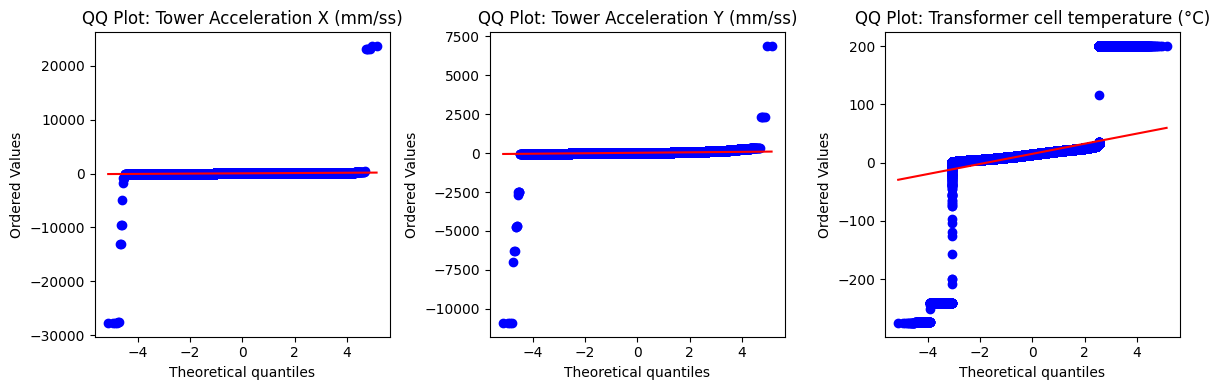

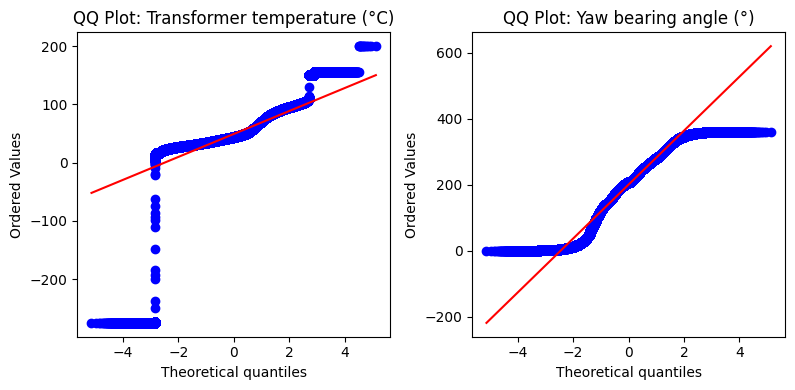

In [5]:
signals_per_fig = 3
cols_per_row = 3
figscale = 4

for idx in range(0, len(cols), signals_per_fig):
    subset = cols[idx:idx+signals_per_fig]
    n_subplots = len(subset)
    n_rows = math.ceil(n_subplots / cols_per_row)
    
    fig, axes = plt.subplots(
        n_rows, cols_per_row,
        figsize=(figscale*cols_per_row, figscale*n_rows),
        squeeze=False
    )
    axes = axes.flatten()
    for j, sig in enumerate(subset):
        probplot(df_turbines[sig], dist="norm", plot=axes[j])
        axes[j].set_title(f"QQ Plot: {sig}")

        
    for empty_ax in axes.flatten()[n_subplots:]:
        empty_ax.remove()
    
    plt.tight_layout()
    plt.show()

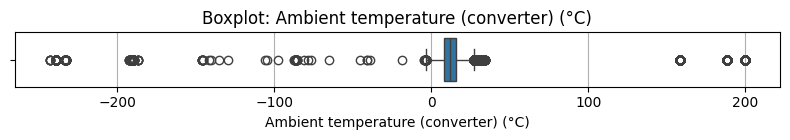

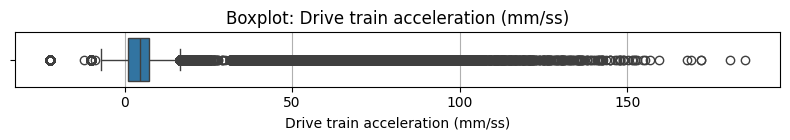

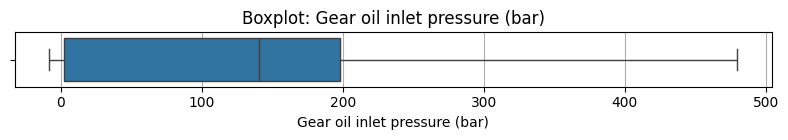

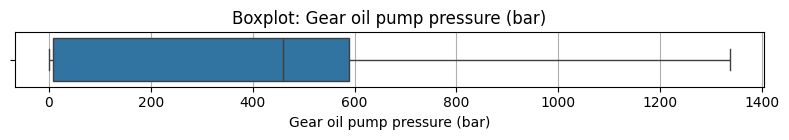

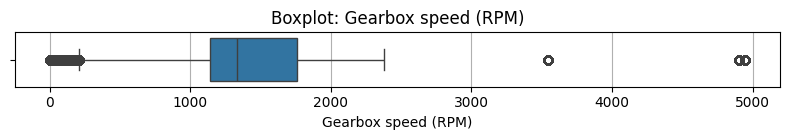

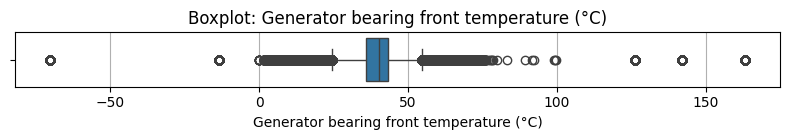

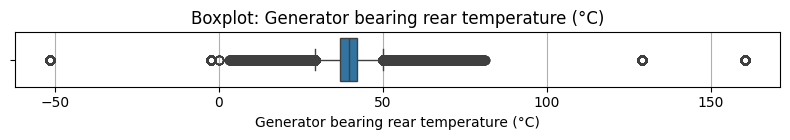

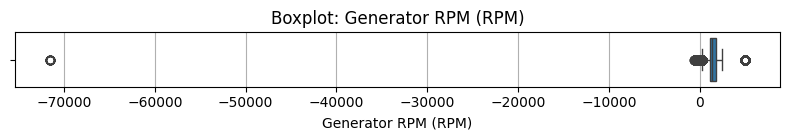

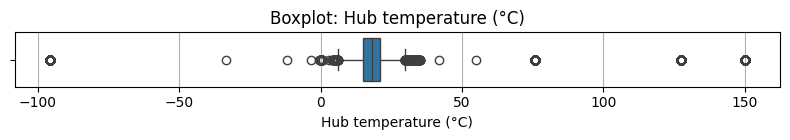

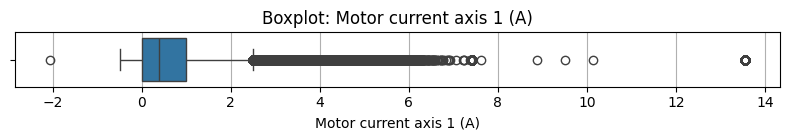

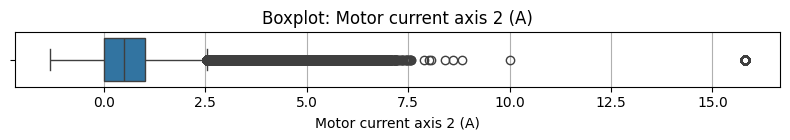

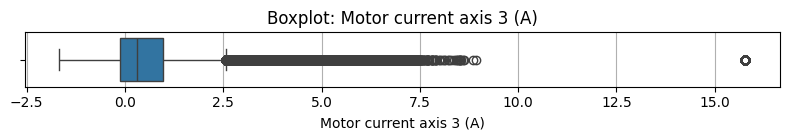

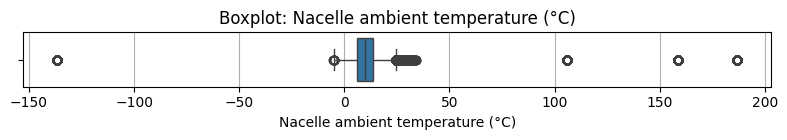

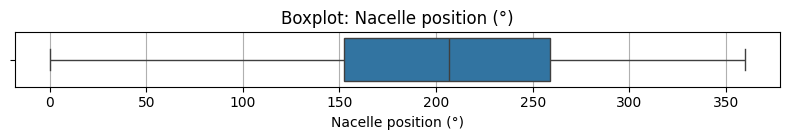

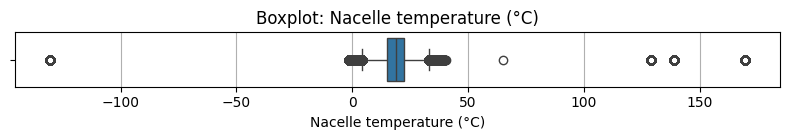

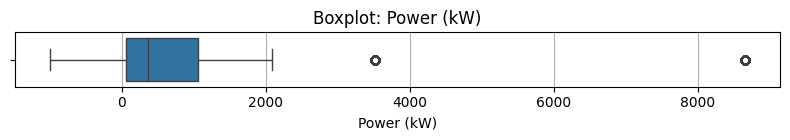

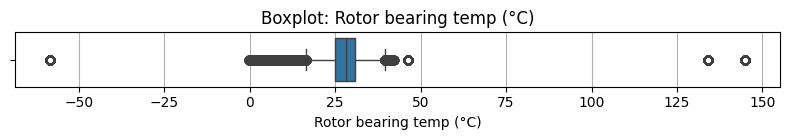

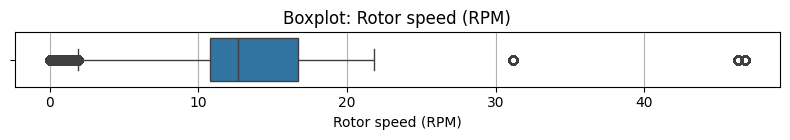

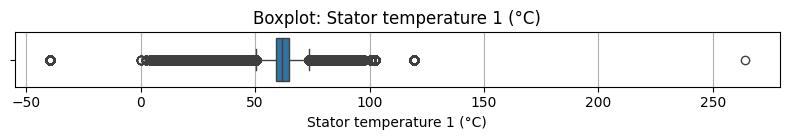

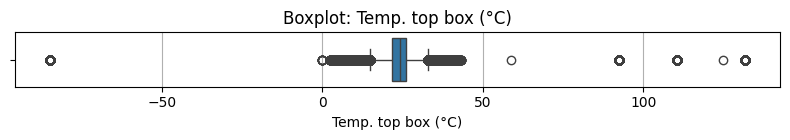

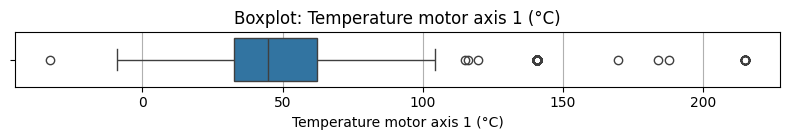

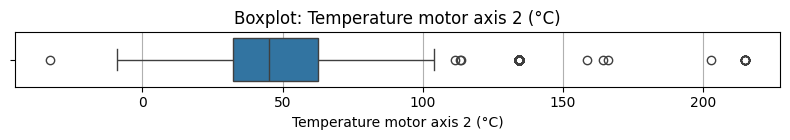

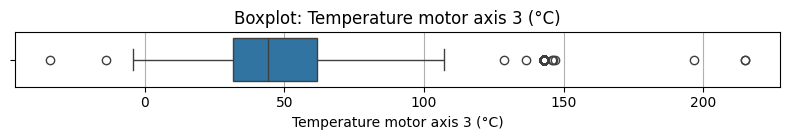

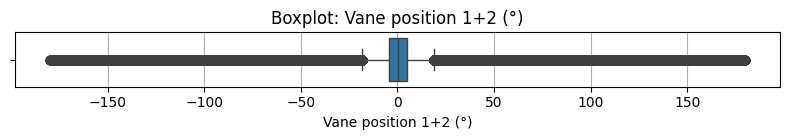

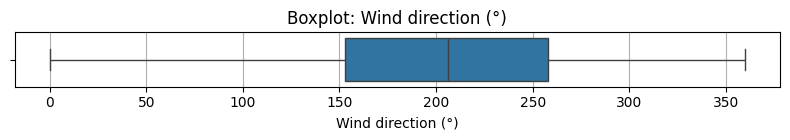

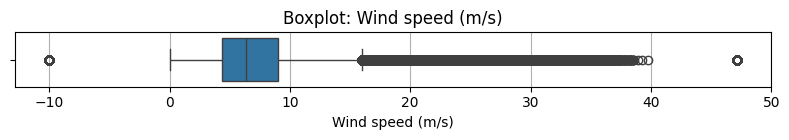

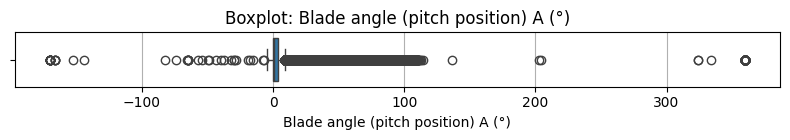

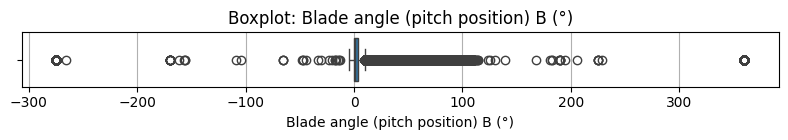

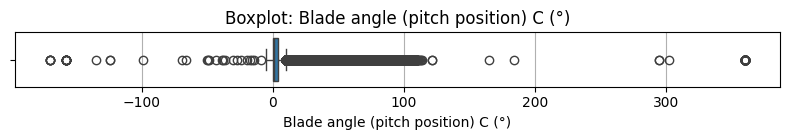

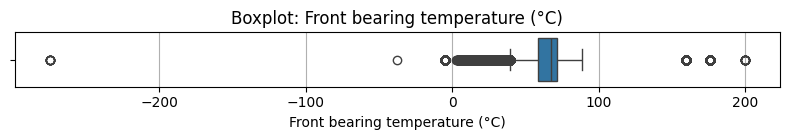

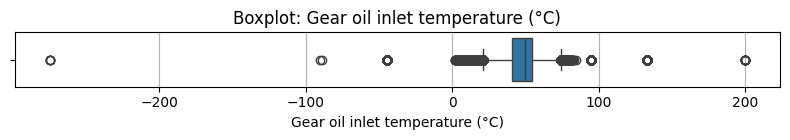

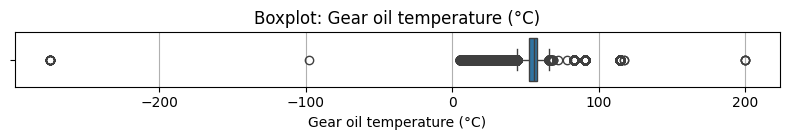

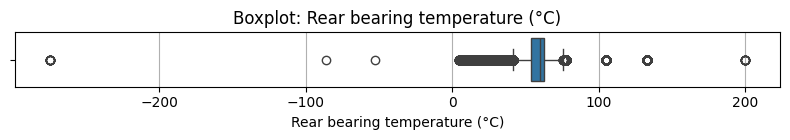

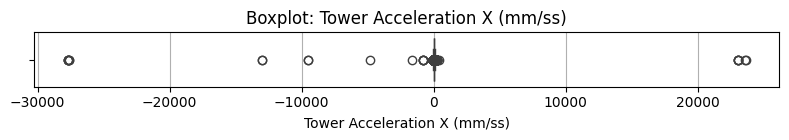

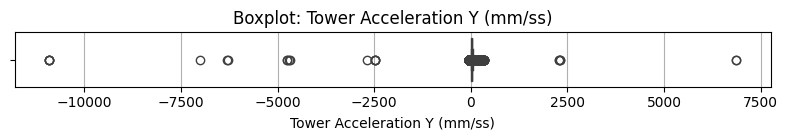

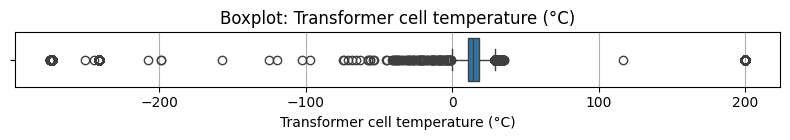

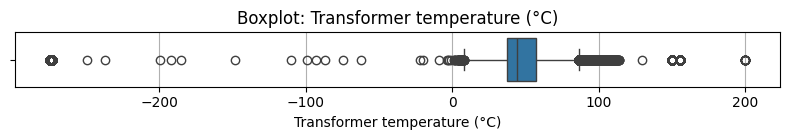

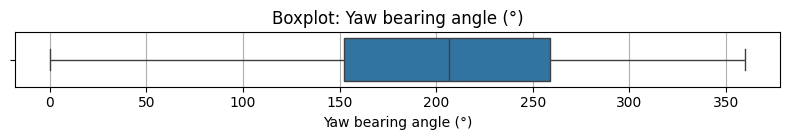

In [6]:
for signal in cols:
    plt.figure(figsize=(8,1.5))
    sns.boxplot(x=df_turbines[signal], orient="h")
    plt.title(f"Boxplot: {signal}")
    plt.xlabel(signal)
    plt.grid(True, axis="x")
    plt.tight_layout()
    plt.show()